# Figure:  Matrix of starting parameters chosen for each basaltic system for all degassing simulations
Numerical values provided to all tool authors are given in Table 1. The redox value for Fogo was given to the authors as ΔNNO+0.7 and converted to Fe3+/ΣFe using the Kress and Carmichael [1991] calculator of Iacovino [2021] at 5000 bar in this figure.

In [4]:
import matplotlib.pyplot as plt

SAVE_FIG = True

## Define data values and styling

In [5]:
CO2_and_S = {
    "S wt%":   {"MORB": 0.142, "Kilauea": 0.15, "Fuego": 0.265, "Fogo": 0.469},
    "CO2 wt%": {"MORB": 0.11, "Kilauea": 0.08, "Fuego": 0.33, "Fogo": 1.152},
}

H2O_vals = {
    "H2O wt%": {"MORB": 0.2, "Kilauea": 0.3, "Fuego": 4.5, "Fogo": 2.11},
}

temperature = {
    "T degC": {"MORB": 1100, "Kilauea": 1200, "Fuego": 1030, "Fogo": 1200}
}

redox = {
    "Fe3/FeT": {"MORB": 0.1, "Kilauea": 0.18, "Fuego": 0.24, "Fogo": 0.27}
}

series_colors = {
    "MORB":    "#84b45f",
    "Kilauea": "#d63d60",
    "Fuego":   "#62acd9",
    "Fogo":    "#ab9ad5",
}

series_order = list(series_colors.keys())  # legend / draw order

## Build the Figure 

/var/folders/_g/9blqt5_91sz3mq5rd0y93qp40000gq/T/ipykernel_36015/3622786235.py:76: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


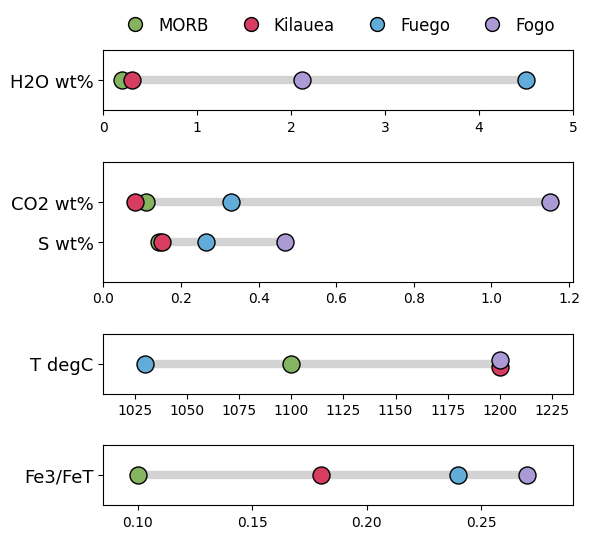

In [6]:

fig, axes = plt.subplots(
    4, 1, figsize=(6, 5.5), gridspec_kw={"height_ratios": [1, 2, 1, 1]}
)
row_spacing = 0.5

H2O_plot = {
    "data": H2O_vals,
    "axis": axes[0],
    "y_positions": {cat: i * row_spacing for i, cat in enumerate(list(H2O_vals.keys()))},
}

CO2_and_S_plot = {
    "data": CO2_and_S,
    "axis": axes[1],
    "y_positions": {cat: i * row_spacing for i, cat in enumerate(list(CO2_and_S.keys()))},
}

temp_plot = {
    "data": temperature,
    "axis": axes[2],
    "y_positions": {cat: i for i, cat in enumerate(list(temperature.keys()))},
    "y_offsets": {"Kilauea": -0.06, "Fogo": 0.06}, # vertical offset for equal temp vals
}

redox_plot = {
    "data": redox,
    "axis": axes[3],
    "y_positions": {cat: i for i, cat in enumerate(list(redox.keys()))},
}


for plotpanel in [H2O_plot, CO2_and_S_plot, temp_plot, redox_plot]:
    # ---- GRAY COLOR BAR ---- #
    for cat, values in plotpanel["data"].items():
        y = plotpanel["y_positions"][cat]
        lo, hi = min(values.values()), max(values.values())
        plotpanel["axis"].plot([lo, hi], [y, y], color="lightgray", linewidth=6,
                solid_capstyle="round", zorder=1)

    # ---- DATA POINTS ---- #
    y_offsets = plotpanel.get("y_offsets", {})
    for series in series_order:
        xs, ys = [], []
        for cat, values in plotpanel["data"].items():
            if series in values:
                xs.append(values[series])
                ys.append(plotpanel["y_positions"][cat] + y_offsets.get(series, 0))
        plotpanel["axis"].scatter(xs, ys, color=series_colors[series], s=150,
                zorder=3, label=series, edgecolors="#000000")

    # ---- AXIS STYLING ---- #
    
    plotpanel["axis"].set_yticks(list(plotpanel["y_positions"].values()))
    plotpanel["axis"].set_yticklabels(list(plotpanel["y_positions"].keys()), fontsize=13)
    plotpanel["axis"].set_ylim(-row_spacing, (len(plotpanel["y_positions"]) - 1) * row_spacing + row_spacing)

    axes[0].set_xlim(0, 5)
    axes[1].set_xlim(0,1.21) # CO2 and S panel only
    axes[2].set_xlim(1010,1235) # temperature panel only
    axes[3].set_xlim(0.085,0.29) # redox panel only
    axes[3].set_xticks([0.1,0.15,0.2,0.25])


# ---- LEGEND ---- #
handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=10,
                      mec="k",
                       color=series_colors[s], label=s) for s in series_order]
legend = axes[0].legend(handles=handles, loc="lower left", bbox_to_anchor=(0, 1.02),
                    ncol=len(series_order), frameon=False, fontsize=12,
                    handletextpad=0.4, columnspacing=1.5)

plt.tight_layout(h_pad=2)

if SAVE_FIG:
    fig.savefig("figures/Fig_VolcanoParameterMatrix.png", dpi=300)
fig.show()